# Low-cost sensor correction with multiple linear regression

In this tutorial we calibrate a PurpleAir low-cost sensor against the US Embassy
reference monitor in Accra. We will:

1. Load PurpleAir 2-minute data and the Embassy hourly reference
2. Average to daily and hourly means and compare baseline performance
3. Fit a multiple linear regression: `embassy_PM2.5 ~ purpleair_PM2.5 + T + RH`
4. Evaluate the corrected sensor and look at the diurnal profile

In [1]:
import fsspec
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

## 1. Load the PurpleAir data

The PurpleAir data is a zip of one-CSV-per-day files, hosted at the URL below.
We use `fsspec` to open every CSV inside the zip without downloading or
unpacking it ourselves. 

In [2]:
PURPLE_URL  = 'https://www.ldeo.columbia.edu/~danielmw/purpleair.zip'
EMBASSY_URL = 'https://www.ldeo.columbia.edu/~danielmw/Accra_PM2.5_2020_YTD.csv'

keep_cols = ['UTCDateTime', 'current_temp_f', 'current_humidity', 'pm2_5_atm', 'pm2_5_atm_b']


files = fsspec.open_files(f'zip://aqm/*.csv::simplecache::{PURPLE_URL}')
purple = pd.concat([pd.read_csv(f.open(), usecols=keep_cols) for f in files], ignore_index=True)
purple.head()

,UTCDateTime,current_temp_f,current_humidity,pm2_5_atm,pm2_5_atm_b
0,2020/03/02T12:16:56z,98.0,49.0,22.20,20.38
1,2020/03/02T12:18:56z,98.0,49.0,35.76,33.39
2,2020/03/02T12:20:56z,98.0,48.0,23.90,23.21
3,2020/03/02T12:22:56z,98.0,47.0,21.59,22.47
4,2020/03/02T12:24:56z,99.0,47.0,19.41,20.71


In [3]:
purple['date'] = pd.to_datetime(purple['UTCDateTime'], format='%Y/%m/%dT%H:%M:%Sz', exact=False, errors='coerce')
purple = purple.dropna().sort_values('date').reset_index(drop=True)

purple['pm2_5_avg'] = purple[['pm2_5_atm', 'pm2_5_atm_b']].mean(axis=1)
purple['temp_C'] = (purple['current_temp_f'] - 32) * 5/9
purple.head()

,UTCDateTime,current_temp_f,current_humidity,pm2_5_atm,pm2_5_atm_b,date,pm2_5_avg,temp_C
0,2020/03/02T12:16:56z,98.0,49.0,22.20,20.38,2020-03-02 12:16:56,21.290,36.666667
1,2020/03/02T12:18:56z,98.0,49.0,35.76,33.39,2020-03-02 12:18:56,34.575,36.666667
2,2020/03/02T12:20:56z,98.0,48.0,23.90,23.21,2020-03-02 12:20:56,23.555,36.666667
3,2020/03/02T12:22:56z,98.0,47.0,21.59,22.47,2020-03-02 12:22:56,22.030,36.666667
4,2020/03/02T12:24:56z,99.0,47.0,19.41,20.71,2020-03-02 12:24:56,20.060,37.222222


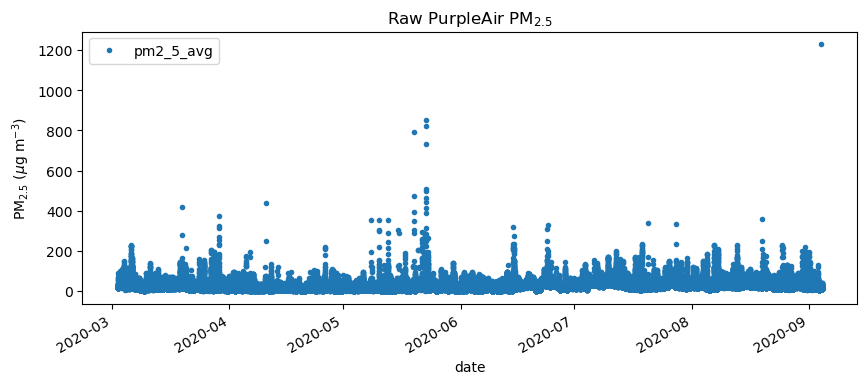

In [4]:
purple.plot(x='date', y='pm2_5_avg', marker='.', linestyle='none', figsize=(10, 4))


## 2. Load the US Embassy reference data

In [5]:
embassy = pd.read_csv(EMBASSY_URL)
embassy['date'] = pd.to_datetime(embassy['Date (LT)'])
embassy = embassy[embassy['Raw Conc.'] > 0]
embassy.head()

/var/folders/d3/z1hh03l929gdlgfh23vm9h0c0000gp/T/ipykernel_17560/3937206664.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  embassy['date'] = pd.to_datetime(embassy['Date (LT)'])


,Site,Parameter,Date (LT),Year,Month,Day,Hour,NowCast Conc.,AQI,AQI Category,Raw Conc.,Conc. Unit,Duration,QC Name,date
29,Accra,PM2.5 - Principal,2020-01-28 10:00 PM,2020,1,28,22,-999.0,-999,NaN,1.0,UG/M3,1 Hr,Invalid,2020-01-28 22:00:00
68,Accra,PM2.5 - Principal,2020-01-30 05:00 PM,2020,1,30,17,-999.0,-999,NaN,58.0,UG/M3,1 Hr,Valid,2020-01-30 17:00:00
69,Accra,PM2.5 - Principal,2020-01-30 06:00 PM,2020,1,30,18,63.9,155,Unhealthy,69.0,UG/M3,1 Hr,Valid,2020-01-30 18:00:00
70,Accra,PM2.5 - Principal,2020-01-30 07:00 PM,2020,1,30,19,63.2,155,Unhealthy,62.0,UG/M3,1 Hr,Valid,2020-01-30 19:00:00
71,Accra,PM2.5 - Principal,2020-01-30 08:00 PM,2020,1,30,20,60.8,154,Unhealthy,56.0,UG/M3,1 Hr,Valid,2020-01-30 20:00:00


## 3. Resample both datasets to daily averages and merge

In [6]:
purple_day = (purple.groupby(purple['date'].dt.floor('d'))
                    .agg(purpleair_pm2_5=('pm2_5_avg', 'mean'),
                         temp=('temp_C', 'mean'),
                         RH=('current_humidity', 'mean'))
                    .reset_index())

embassy_day = (embassy.groupby(embassy['date'].dt.floor('d'))
                      .agg(embassy_pm2_5=('Raw Conc.', 'mean'))
                      .reset_index())

daily = pd.merge(purple_day, embassy_day, on='date')
daily.head()

,date,purpleair_pm2_5,temp,RH,embassy_pm2_5
0,2020-03-02,32.923952,34.337425,56.065156,48.333333
1,2020-03-03,49.739841,31.695137,59.667590,46.708333
2,2020-03-04,40.263677,33.425669,55.254848,32.291667
3,2020-03-05,31.880970,34.014312,56.290859,32.583333
4,2020-03-06,48.299910,32.860111,55.826870,45.458333


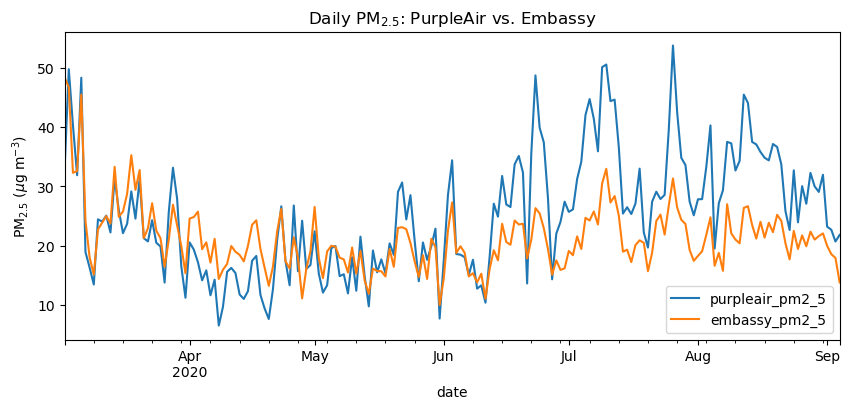

In [7]:
daily.plot(x='date', y=['purpleair_pm2_5', 'embassy_pm2_5'], figsize=(10, 4))
plt.ylabel('PM$_{2.5}$ ($\mu$g m$^{-3}$)')

## 4. Performance evaluation of raw data

In [8]:
def rsquared(x, y):
    return linregress(x, y).rvalue ** 2

R2_raw  = rsquared(daily['embassy_pm2_5'], daily['purpleair_pm2_5'])
MAE_raw = mean_absolute_error(daily['embassy_pm2_5'], daily['purpleair_pm2_5'])
print(f'Raw  R^2 = {R2_raw:.3f}')
print(f'Raw  MAE = {MAE_raw:.2f} ug/m3')

Raw  R^2 = 0.479
Raw  MAE = 6.54 ug/m3


## 5. Train the MLR correction

Model: `embassy_PM2.5 = b0 + b1*purpleair + b2*T + b3*RH`

80/20 train/test split with a fixed random seed so the result is reproducible.

In [9]:
features = ['purpleair_pm2_5', 'temp', 'RH']
target   = 'embassy_pm2_5'

train, test = train_test_split(daily, test_size=0.2, random_state=70)

model = LinearRegression().fit(train[features], train[target])

coefs = dict(zip(features, model.coef_.round(3)))
print('Coefficients:', coefs)
print(f'Intercept   : {model.intercept_:.3f}')

Coefficients: {'purpleair_pm2_5': np.float64(0.488), 'temp': np.float64(0.445), 'RH': np.float64(-0.164)}
Intercept   : 4.932


## 6. Evaluate on the held-out test set and apply to all days

In [10]:
test = test.copy()
test['pm2_5_corrected'] = model.predict(test[features])

R2_test  = model.score(test[features], test[target])
MAE_test = mean_absolute_error(test[target], test['pm2_5_corrected'])

print(f'Corrected  R^2 = {R2_test:.3f}   ')
print(f'Corrected  MAE = {MAE_test:.2f} ug/m3  ')

Corrected  R^2 = 0.497   (raw was 0.479)
Corrected  MAE = 2.57 ug/m3   (raw was 6.54)


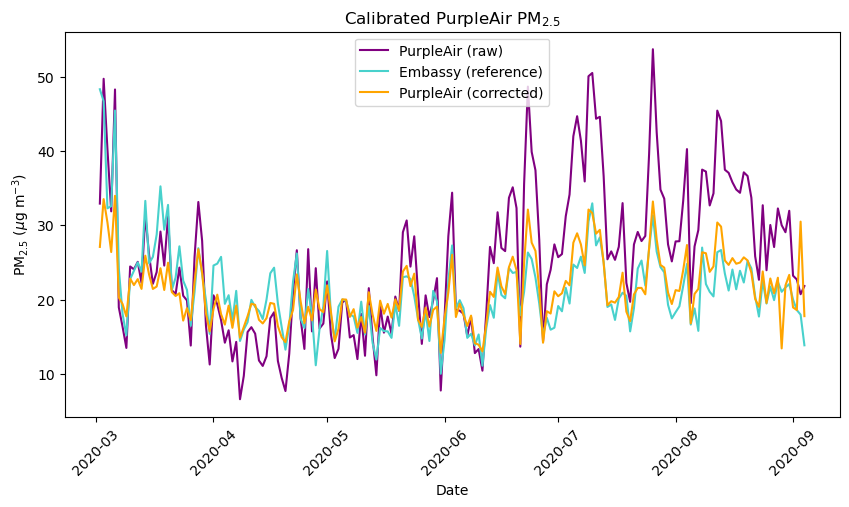

In [11]:
daily['pm2_5_corrected'] = model.predict(daily[features])

plt.figure(figsize=(10, 5))
plt.plot(daily['date'], daily['purpleair_pm2_5'],   label='PurpleAir (raw)',       color='purple')
plt.plot(daily['date'], daily['embassy_pm2_5'],     label='Embassy (reference)',   color='mediumturquoise')
plt.plot(daily['date'], daily['pm2_5_corrected'],   label='PurpleAir (corrected)', color='orange')
plt.xlabel('Date')
plt.ylabel('PM$_{2.5}$ ($\mu$g m$^{-3}$)')
plt.xticks(rotation=45)
plt.legend(loc='upper center');

## 7. Hourly-resolved MLR correction



In [12]:
purple_hr = (purple.groupby(purple['date'].dt.floor('h'))
                   .agg(purpleair_pm2_5=('pm2_5_avg', 'mean'),
                        temp=('temp_C', 'mean'),
                        RH=('current_humidity', 'mean'))
                   .reset_index())

embassy_hr = (embassy.assign(date=embassy['date'].dt.floor('h'))
                     .groupby('date')
                     .agg(embassy_pm2_5=('Raw Conc.', 'mean'))
                     .reset_index())

hourly = pd.merge(purple_hr, embassy_hr, on='date')

train_h, test_h = train_test_split(hourly, test_size=0.2, random_state=70)
model_hourly = LinearRegression().fit(train_h[features], train_h[target])

R2_hr  = model_hourly.score(test_h[features], test_h[target])
MAE_hr = mean_absolute_error(test_h[target], model_hourly.predict(test_h[features]))

print('Hourly coefficients:', dict(zip(features, model_hourly.coef_.round(3))))
print(f'Hourly intercept   : {model_hourly.intercept_:.3f}')
print(f'Hourly  MAE = {MAE_hr:.2f} ug/m3   ')

Hourly coefficients: {'purpleair_pm2_5': np.float64(0.362), 'temp': np.float64(-0.013), 'RH': np.float64(-0.207)}
Hourly intercept   : 24.989
Hourly  MAE = 5.71 ug/m3   (daily model MAE was 2.57)


## 8. Diurnal profile

In [13]:

X_purple = purple[['pm2_5_avg', 'temp_C', 'current_humidity']].rename(
    columns={'pm2_5_avg': 'purpleair_pm2_5', 'temp_C': 'temp', 'current_humidity': 'RH'})

purple['pm2_5_corr_daily']  = model.predict(X_purple)
purple['pm2_5_corr_hourly'] = model_hourly.predict(X_purple)

purple['hour']  = purple['date'].dt.hour
embassy['hour'] = embassy['date'].dt.hour

diurnal = pd.DataFrame({
    'PurpleAir (raw)':              purple.groupby('hour')['pm2_5_avg'].mean(),
    'PurpleAir (daily MLR)':        purple.groupby('hour')['pm2_5_corr_daily'].mean(),
    'PurpleAir (hourly MLR)':       purple.groupby('hour')['pm2_5_corr_hourly'].mean(),
    'Embassy (reference)':          embassy.groupby('hour')['Raw Conc.'].mean(),
})
diurnal

,PurpleAir (raw),PurpleAir (daily MLR),PurpleAir (hourly MLR),Embassy (reference)
hour,,,,
0,32.575909,23.513510,21.355403,28.982036
1,27.197465,20.254888,20.765027,30.462462
2,26.561161,19.868427,20.511206,27.533133
3,27.611877,20.263527,20.833871,27.900602
4,29.982570,21.362101,21.669852,28.093656
5,36.284400,24.445809,23.980214,29.936170
6,44.901778,28.843751,27.236844,33.200608
7,41.666258,28.229495,26.719974,39.352584
8,31.160226,24.729624,24.048453,38.835866


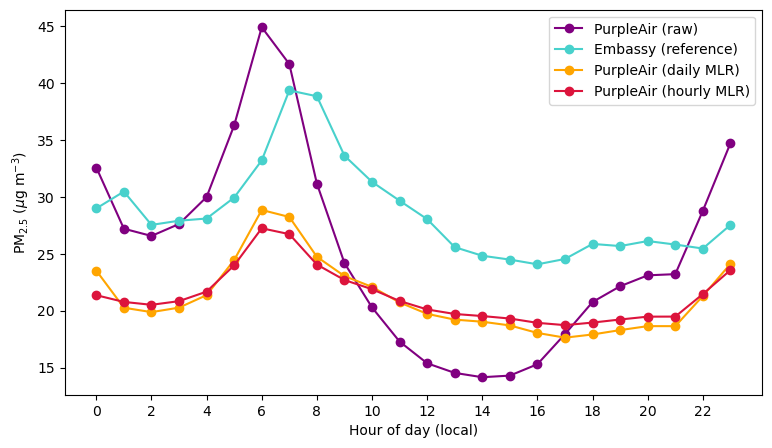

In [14]:
plt.figure(figsize=(9, 5))
plt.plot(diurnal.index, diurnal['PurpleAir (raw)'],        marker='o', color='purple',         label='PurpleAir (raw)')
plt.plot(diurnal.index, diurnal['Embassy (reference)'],    marker='o', color='mediumturquoise', label='Embassy (reference)')
plt.plot(diurnal.index, diurnal['PurpleAir (daily MLR)'],  marker='o', color='orange',         label='PurpleAir (daily MLR)')
plt.plot(diurnal.index, diurnal['PurpleAir (hourly MLR)'], marker='o', color='crimson',        label='PurpleAir (hourly MLR)')
plt.xticks(range(0, 24, 2))
plt.xlabel('Hour of day (local)')
plt.ylabel('PM$_{2.5}$ ($\\mu$g m$^{-3}$)')
plt.legend();